In [ ]:
# Install required packages
!pip install pandas matplotlib seaborn deep-translator retry -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np


Sentiment Distribution:
          Count  Percentage
Sentimen                   
Bandang     909       57.86
Banjir      662       42.14


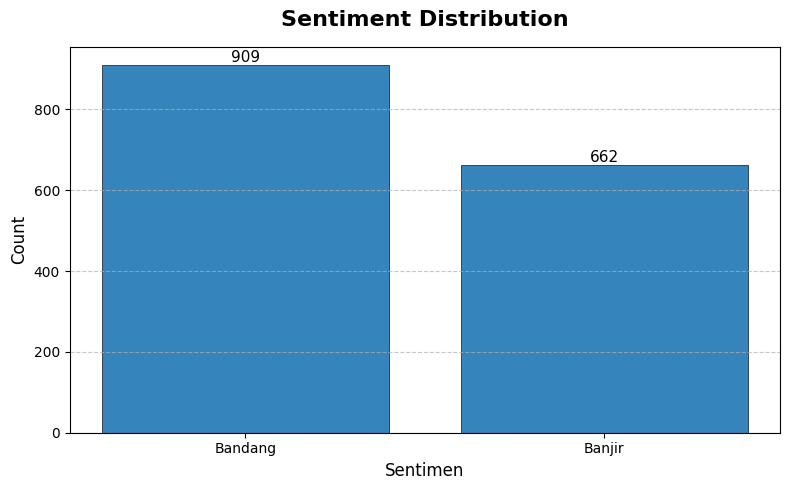

In [ ]:
# Load dataset
df = pd.read_csv('data_banjir_clean.csv')

# Count the number of data for each sentiment
sentiment_counts = df['Sentimen'].value_counts()

# Calculate the percentage of each sentiment
sentiment_percentage = df['Sentimen'].value_counts(normalize=True) * 100

# Combine counts and percentages into one DataFrame
sentiment_summary = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage': sentiment_percentage.round(2)
})

print("Sentiment Distribution:")
print(sentiment_summary)

# Visualize sentiment distribution
plt.figure(figsize=(8, 5))
bars = plt.bar(
    sentiment_summary.index,
    sentiment_summary['Count'],
    edgecolor='black',
    linewidth=0.5,
    alpha=0.9
)

plt.title("Sentiment Distribution", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Sentimen", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add value labels on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Check class imbalance ratio
max_count = sentiment_counts.max()
min_count = sentiment_counts.min()
imbalance_ratio = max_count / min_count

print(f"\nImbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio >= 1.2:
    print("The dataset is imbalanced. Balancing is recommended.")
else:
    print("The dataset is relatively balanced. Balancing may not be necessary.")


Imbalance ratio: 1.37
The dataset is imbalanced. Balancing is recommended.


In [ ]:
# Define protected words that should not be replaced
protected_words = {
    'banjir', 'bandang', 'makassar', 'sulsel', 'bpbd', 'pemerintah', 'bupati'
}

# Define custom Indonesian synonyms for Flood-related text
banjir_synonyms_dict = {
    "warga": ["masyarakat", "penduduk"],
    "masyarakat": ["warga", "penduduk"],
    "mengungsi": ["berlindung", "berpindah", "evakuasi"],
    "evakuasi": ["penyelamatan", "pemindahan"],
    "bantuan": ["pertolongan", "logistik", "dukungan"],
    "jalan": ["akses", "jalur", "rute"],
    "hujan": ["curah hujan", "presipitasi"],
    "rumah": ["hunian", "tempat tinggal", "pemukiman"],
    "rusak": ["hancur", "terdampak"],
    "korban": ["warga terdampak"],
    "meningkatkan": ["menaikkan", "memperparah"],
    "menurunkan": ["mengurangi", "menyurutkan"],
    "air": ["genangan", "luapan"],
    "cepat": ["segera", "lekas"],
    "lambat": ["pelan", "terhambat"],
    "daerah": ["wilayah", "kawasan"],
    "kendaraan": ["transportasi", "motor dan mobil"]
}

In [ ]:
import re
import random
import time
import logging
from multiprocessing import Pool
from retry import retry
from deep_translator import GoogleTranslator

# ==============================
# 1. SETUP & CONFIG
# ==============================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

TEXT_COL = 'Judul' # Kita lakukan di Judul agar proses tidak terlalu lama
AUG_COL = 'augmented_judul'
LABEL_COL = 'Sentimen'

# ==============================
# 2. CLEANING FUNCTION
# ==============================
def clean_news_junk(text):
    if not text: return ""
    text = str(text)
    text = re.sub(r"[\[\]']", "", text)
    # Menghapus elemen berita tidak relevan seperti di kode temanmu
    text = re.sub(r"SCROLL TO CONTINUE WITH CONTENT", "", text, flags=re.IGNORECASE)
    text = re.sub(r"ADVERTISEMENT", "", text, flags=re.IGNORECASE)
    return text.strip()

# ==============================
# 3. AUGMENTATION WORKERS
# ==============================
def synonym_replacement(text, rate=0.15):
    words = text.split()
    if len(words) < 3: return text
    new_words = []
    for word in words:
        clean_w = re.sub(r'[^a-zA-Z]', '', word.lower())
        if clean_w in banjir_synonyms_dict and random.random() < rate and clean_w not in protected_words:
            new_words.append(random.choice(banjir_synonyms_dict[clean_w]))
        else:
            new_words.append(word)
    return " ".join(new_words)

@retry(tries=3, delay=5, backoff=2)
def back_translate(text):
    if len(text) < 10: return text
    try:
        # Translate ID -> EN -> ID
        en_text = GoogleTranslator(source='id', target='en').translate(text)
        time.sleep(random.uniform(1.0, 2.0))
        return GoogleTranslator(source='en', target='id').translate(en_text)
    except Exception as e:
        logger.error(f"BT Error: {e}")
        return text

def augment_process(row):
    original_txt = clean_news_junk(row[TEXT_COL])

    # Logika Temanmu: 70% Back-translation, 30% Hanya Synonym Replacement
    if random.random() > 0.3:
        bt_txt = back_translate(original_txt)
        row[AUG_COL] = synonym_replacement(bt_txt, rate=0.05)
        row['aug_method'] = 'Back-Translation + SR'
    else:
        row[AUG_COL] = synonym_replacement(original_txt, rate=0.2)
        row['aug_method'] = 'Synonym Replacement Only'

    row['is_augmented'] = True
    return row

# ==============================
# 4. RUNNER (TARGETED BALANCING)
# ==============================
if __name__ == '__main__':
    # 1. Pisahkan data berdasarkan label
    df_mayoritas = df[df[LABEL_COL] == 'Bandang'].copy()
    df_minoritas = df[df[LABEL_COL] == 'Banjir'].copy()

    # 2. Hitung kekurangan (Misal Bandang 909, Banjir 662 -> Butuh 247)
    jumlah_kebutuhan = len(df_mayoritas) - len(df_minoritas)

    # Ambil sampel dari minoritas untuk diaugmentasi
    df_minoritas_to_aug = df_minoritas.sample(n=jumlah_kebutuhan, replace=True, random_state=42)

    # 3. Proses Augmentasi Data Minoritas (Banjir)
    logger.info(f"Memulai augmentasi {jumlah_kebutuhan} data kelas 'Banjir' (BT + SR)...")

    # Catatan: Jika kamu jalan di Windows/Mac lokal, Pool(processes=2) bekerja dengan baik
    with Pool(processes=2) as p:
        results_minoritas = p.map(augment_process, [row for _, row in df_minoritas_to_aug.iterrows()])
    df_aug_minoritas = pd.DataFrame(results_minoritas)

    # Rapikan struktur DataFrame baru agar sama dengan yang lama
    df_aug_minoritas['Judul'] = df_aug_minoritas[AUG_COL]
    df_aug_minoritas['Sumber'] = df_aug_minoritas['Sumber'] + ' (' + df_aug_minoritas['aug_method'] + ')'

    # Buang kolom bantuan
    df_aug_minoritas = df_aug_minoritas.drop(columns=[AUG_COL, 'aug_method', 'is_augmented'])

    # 4. Gabungkan Semua Kembali (Mayoritas + Minoritas Asli + Minoritas Augmented)
    df_final = pd.concat([df_mayoritas, df_minoritas, df_aug_minoritas], ignore_index=True)
    df_final['No'] = range(1, len(df_final) + 1)

    # ==============================
    # 5. SAVE & VERIFIKASI
    # ==============================
    print("\n--- Distribusi Akhir Sesuai Target ---")
    print(df_final[LABEL_COL].value_counts())

    nama_output = 'data_banjir_balanced_augmented_v2.csv'
    df_final.to_csv(nama_output, index=False)
    logger.info(f"Data berhasil diseimbangkan dan disimpan di '{nama_output}'")


--- Distribusi Akhir Sesuai Target ---
Sentimen
Bandang    909
Banjir     909
Name: count, dtype: int64


In [ ]:
# Tampilkan 5 data terbawah hasil augmentasi
df_final.tail()

,No,Judul,Link,Sumber,Sentimen,Konten,Tanggal
1813,1814,"DPRD Kalteng Reses di Jekan Raya, Warga Soroti...",https://kaltengonline.com/2026/04/12/reses-dpr...,Lainnya (Back-Translation + SR),Banjir,"PALANGKA RAYA, kaltengonline.com – Kegiatan re...",2026-04-12 00:00:00
1814,1815,Banjir Rob terdampak 20 pemukiman di Desa Bugi...,https://www.detik.com/bali/nusra/d-8332672/ban...,Detik (Back-Translation + SR),Banjir,Banjir rob kembali terjadi di Lingkungan Bugis...,2026-01-30 13:22:02
1815,1816,"Sejumlah Wilayah Terendam, Polsek Pantai Timur...",https://tribratanews.papua.polri.go.id/sejumla...,Tribrata News Polda Papua (Synonym Replacement...,Banjir,Polres Sarmi – Setelah diguyur hujan deras sej...,2025-12-12 15:26:35+00:00
1816,1817,"Banjir di Jalan Paccerakkang Makassar, Ruko Te...",https://www.detik.com/sulsel/makassar/d-837192...,Detik (Back-Translation + SR),Banjir,"Banjir merendam Jalan Paccerakkang, Kecamatan ...",2026-02-25 12:25:13
1817,1818,208 KK warga Passo mengungsi akibat banjir,https://ambon.antaranews.com/berita/20962/208-...,AntaraNews (Back-Translation + SR),Banjir,208 KK Warga Passo Mengungsi Akibat Banjir\n\n...,NaN


In [ ]:
#Install & Import untuk Evaluasi
!pip install nltk scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [ ]:
#Load Data & Pisahkan Asli vs Augmentasi
df_eval = pd.read_csv('data_banjir_balanced_augmented_v2.csv')

# data asli = yang sumbernya tidak mengandung tanda kurung aug method
df_asli = df_eval[~df_eval['Sumber'].str.contains(r'\(', na=False)].copy()
df_aug  = df_eval[df_eval['Sumber'].str.contains(r'\(', na=False)].copy()

print(f'Total data keseluruhan : {len(df_eval)}')
print(f'Data asli              : {len(df_asli)}')
print(f'Data augmentasi        : {len(df_aug)}')
print()
print('Distribusi label setelah augmentasi:')
print(df_eval['Sentimen'].value_counts())

Total data keseluruhan : 1818
Data asli              : 1555
Data augmentasi        : 263

Distribusi label setelah augmentasi:
Sentimen
Bandang    909
Banjir     909
Name: count, dtype: int64


In [ ]:
#Evaluasi 1: BLEU Score
# BLEU score mengukur seberapa mirip teks augmentasi dengan teks aslinya
# semakin rendah = semakin berbeda = semakin bagus untuk augmentasi

smoother = SmoothingFunction().method1

def hitung_bleu(teks_asli, teks_aug):
    if not isinstance(teks_asli, str) or not isinstance(teks_aug, str):
        return 0.0
    ref = teks_asli.lower().split()
    hyp = teks_aug.lower().split()
    if len(hyp) == 0:
        return 0.0
    return sentence_bleu([ref], hyp, smoothing_function=smoother)

# ambil sample 200 pasang asli-augmentasi berdasarkan label yang sama
df_sample_aug  = df_aug.sample(n=min(200, len(df_aug)), random_state=42).reset_index(drop=True)
df_sample_asli = df_asli.sample(n=min(200, len(df_asli)), random_state=42).reset_index(drop=True)

bleu_scores = []
for i in range(len(df_sample_aug)):
    asli = df_sample_asli.loc[i, 'Judul'] if i < len(df_sample_asli) else ''
    aug  = df_sample_aug.loc[i, 'Judul']
    bleu_scores.append(hitung_bleu(asli, aug))

rata_bleu = np.mean(bleu_scores)
print(f'Rata-rata BLEU Score : {rata_bleu:.4f}')
print()
if rata_bleu < 0.3:
    print('Keberagaman TINGGI — teks augmentasi cukup berbeda dari aslinya.')
elif rata_bleu < 0.6:
    print('Keberagaman SEDANG — ada variasi tapi masih mirip.')
else:
    print('Keberagaman RENDAH — teks augmentasi terlalu mirip dengan aslinya.')

Rata-rata BLEU Score : 0.0143

Keberagaman TINGGI — teks augmentasi cukup berbeda dari aslinya.


In [ ]:
#Evaluasi 2: Cosine Similarity
# cosine similarity mengukur kemiripan makna antara teks asli dan augmentasi
# semakin rendah = semakin berbeda maknanya

vectorizer = TfidfVectorizer()

judul_asli = df_sample_asli['Judul'].fillna('').tolist()
judul_aug  = df_sample_aug['Judul'].fillna('').tolist()

all_texts = judul_asli + judul_aug
tfidf_matrix = vectorizer.fit_transform(all_texts)

n = len(judul_asli)
vec_asli = tfidf_matrix[:n]
vec_aug  = tfidf_matrix[n:]

cos_scores = []
for i in range(n):
    sim = cosine_similarity(vec_asli[i], vec_aug[i])[0][0]
    cos_scores.append(sim)

rata_cos = np.mean(cos_scores)
print(f'Rata-rata Cosine Similarity : {rata_cos:.4f}')
print()
if rata_cos < 0.5:
    print('Keberagaman TINGGI — makna teks augmentasi cukup berbeda.')
elif rata_cos < 0.75:
    print('Keberagaman SEDANG.')
else:
    print('Keberagaman RENDAH — makna teks augmentasi terlalu mirip.')

Rata-rata Cosine Similarity : 0.0274

Keberagaman TINGGI — makna teks augmentasi cukup berbeda.


In [ ]:
#Evaluasi 3: Unique Word Ratio
# unique word ratio = seberapa banyak kata baru yang muncul di teks augmentasi
# yang tidak ada di teks aslinya

def unique_word_ratio(teks_asli, teks_aug):
    if not isinstance(teks_asli, str) or not isinstance(teks_aug, str):
        return 0.0
    kata_asli = set(teks_asli.lower().split())
    kata_aug  = set(teks_aug.lower().split())
    if len(kata_aug) == 0:
        return 0.0
    kata_baru = kata_aug - kata_asli
    return len(kata_baru) / len(kata_aug)

uwr_scores = []
for i in range(len(df_sample_aug)):
    asli = df_sample_asli.loc[i, 'Judul'] if i < len(df_sample_asli) else ''
    aug  = df_sample_aug.loc[i, 'Judul']
    uwr_scores.append(unique_word_ratio(asli, aug))

rata_uwr = np.mean(uwr_scores)
print(f'Rata-rata Unique Word Ratio : {rata_uwr:.4f} ({rata_uwr*100:.1f}%)')
print()
if rata_uwr > 0.3:
    print('Banyak kata baru muncul — augmentasi menghasilkan variasi kosakata yang baik.')
else:
    print('Sedikit kata baru — augmentasi kurang menghasilkan variasi kosakata.')

Rata-rata Unique Word Ratio : 0.8948 (89.5%)

Banyak kata baru muncul — augmentasi menghasilkan variasi kosakata yang baik.


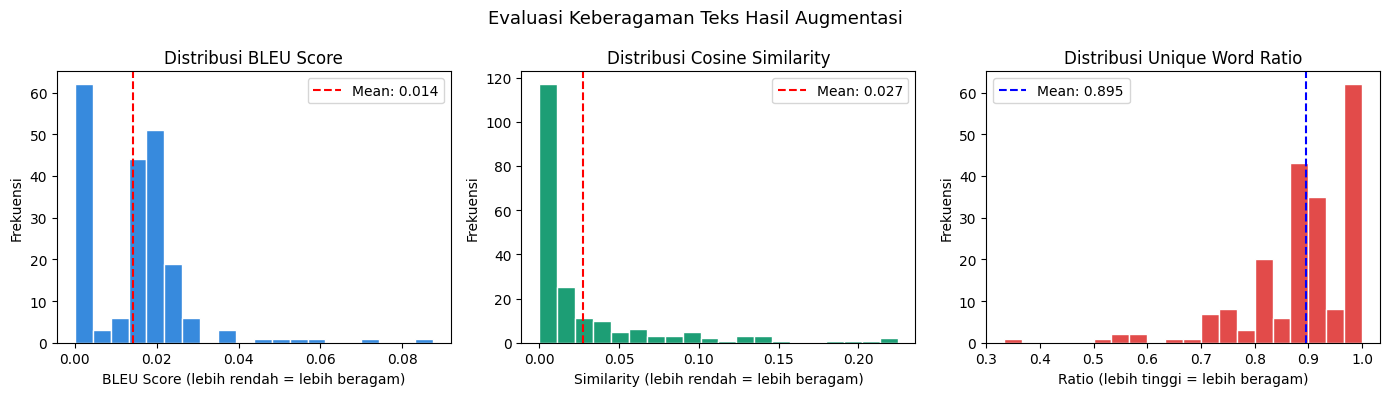

In [ ]:
#Visualisasi Semua Metrik
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# BLEU Score distribution
axes[0].hist(bleu_scores, bins=20, color='#378ADD', edgecolor='white')
axes[0].axvline(rata_bleu, color='red', linestyle='--', label=f'Mean: {rata_bleu:.3f}')
axes[0].set_title('Distribusi BLEU Score')
axes[0].set_xlabel('BLEU Score (lebih rendah = lebih beragam)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Cosine Similarity distribution
axes[1].hist(cos_scores, bins=20, color='#1D9E75', edgecolor='white')
axes[1].axvline(rata_cos, color='red', linestyle='--', label=f'Mean: {rata_cos:.3f}')
axes[1].set_title('Distribusi Cosine Similarity')
axes[1].set_xlabel('Similarity (lebih rendah = lebih beragam)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

# Unique Word Ratio distribution
axes[2].hist(uwr_scores, bins=20, color='#E24B4A', edgecolor='white')
axes[2].axvline(rata_uwr, color='blue', linestyle='--', label=f'Mean: {rata_uwr:.3f}')
axes[2].set_title('Distribusi Unique Word Ratio')
axes[2].set_xlabel('Ratio (lebih tinggi = lebih beragam)')
axes[2].set_ylabel('Frekuensi')
axes[2].legend()

plt.suptitle('Evaluasi Keberagaman Teks Hasil Augmentasi', fontsize=13)
plt.tight_layout()
plt.savefig('evaluasi_keberagaman.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Ringkasan Akhir
print('=' * 50)
print('RINGKASAN EVALUASI KEBERAGAMAN TEKS')
print('=' * 50)
print(f'Jumlah data augmentasi  : {len(df_aug)}')
print(f'Sample yang dievaluasi  : {len(df_sample_aug)}')
print()
print(f'BLEU Score              : {rata_bleu:.4f}')
print(f'Cosine Similarity       : {rata_cos:.4f}')
print(f'Unique Word Ratio       : {rata_uwr:.4f} ({rata_uwr*100:.1f}%)')
print()
print('Kesimpulan:')
if rata_bleu < 0.4 and rata_cos < 0.7 and rata_uwr > 0.2:
    print('Hasil augmentasi memiliki keberagaman yang BAIK.')
    print('Teks augmentasi cukup berbeda dari teks asli secara struktur dan makna.')
else:
    print('Hasil augmentasi memiliki keberagaman yang CUKUP.')
    print('Beberapa teks augmentasi masih mirip dengan teks aslinya.')

RINGKASAN EVALUASI KEBERAGAMAN TEKS
Jumlah data augmentasi  : 263
Sample yang dievaluasi  : 200

BLEU Score              : 0.0143
Cosine Similarity       : 0.0274
Unique Word Ratio       : 0.8948 (89.5%)

Kesimpulan:
Hasil augmentasi memiliki keberagaman yang BAIK.
Teks augmentasi cukup berbeda dari teks asli secara struktur dan makna.


Tabel Distribusi Kelas:
          Sebelum Augmentasi  Sesudah Augmentasi
Sentimen                                        
Bandang                  909                 909
Banjir                   646                 909
--------------------------------------------------


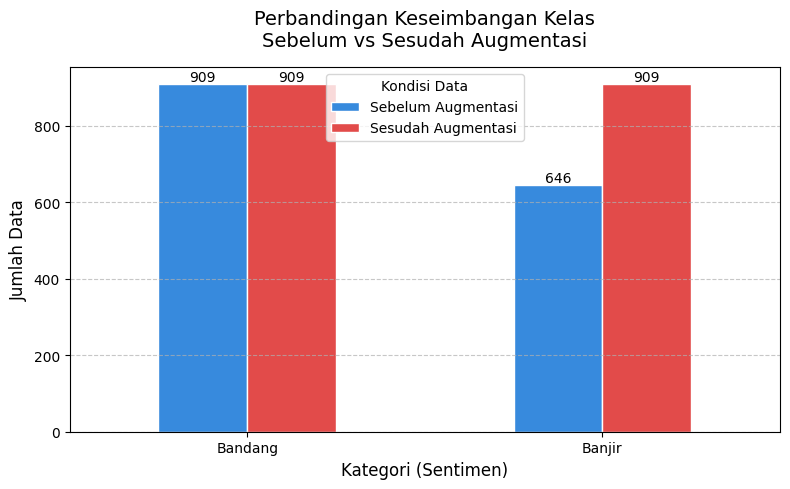

In [ ]:
# Evaluasi Relevansi 1: Distribusi Label Sebelum vs Sesudah Augmentasi
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung jumlah data sebelum augmentasi (data asli saja)
dist_sebelum = df_asli['Sentimen'].value_counts()

# Menghitung jumlah data setelah augmentasi (semua data gabungan)
dist_sesudah = df_eval['Sentimen'].value_counts()

# Gabungkan menjadi satu DataFrame agar mudah dilihat
df_dist = pd.DataFrame({
    'Sebelum Augmentasi': dist_sebelum,
    'Sesudah Augmentasi': dist_sesudah
}).fillna(0).astype(int)

print("Tabel Distribusi Kelas:")
print(df_dist)
print("-" * 50)

# Visualisasi Bar Chart
ax = df_dist.plot(kind='bar', figsize=(8, 5), color=['#378ADD', '#E24B4A'], edgecolor='white')
plt.title('Perbandingan Keseimbangan Kelas\nSebelum vs Sesudah Augmentasi', fontsize=14, pad=15)
plt.xlabel('Kategori (Sentimen)', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menambahkan angka di atas bar
for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', fontsize=10)

plt.legend(title="Kondisi Data")
plt.tight_layout()
plt.show()

Jumlah Teks Augmentasi        : 263
Jumlah Teks yang Tetap Relevan: 261
Persentase Relevansi Keyword  : 99.24%



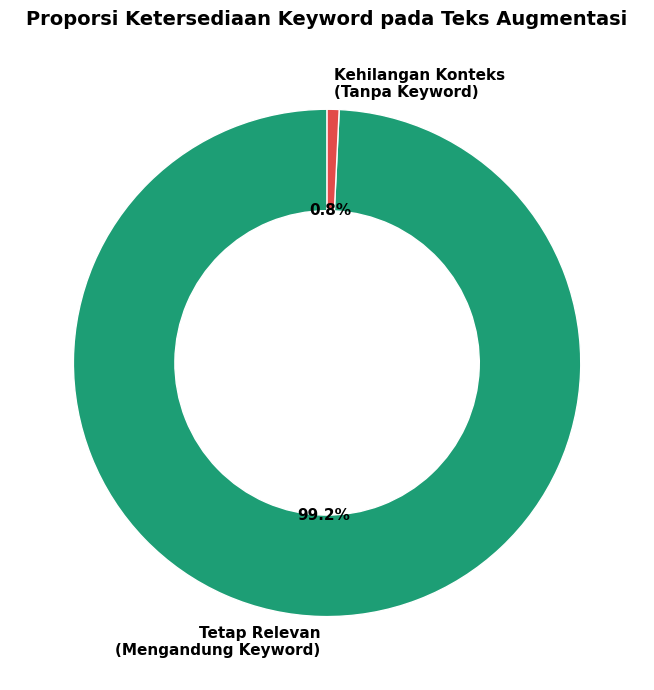


⚠️ Ditemukan 2 teks augmentasi yang kehilangan keyword intinya.
Contoh Teks yang kehilangan keyword (Perlu dicek manual):


,Judul,Sentimen,Sumber
1612,"Diguyur Hujan Deras, Jalanan di Siwalankerto S...",Banjir,Detik (Synonym Replacement Only)
1769,"Sungai Taritatu Meluap, Puluhan Rumah di Mambe...",Banjir,detiknews (Back-Translation + SR)


In [ ]:
# Evaluasi Relevansi 2: Ketersediaan Keyword Khas Bencana + Visualisasi
import matplotlib.pyplot as plt

# 1. Tentukan kata kunci yang sangat mencerminkan tiap kelas
keywords_banjir = ['banjir', 'terendam', 'merendam', 'genangan', 'air', 'luapan', 'banjir rob']
keywords_bandang = ['bandang', 'deras', 'lumpur', 'hancur', 'rusak', 'tersapu']

# 2. Fungsi untuk mengecek eksistensi keyword
def cek_relevansi_keyword(text, label):
    if not isinstance(text, str):
        return False
    text_lower = text.lower()

    if label == 'Banjir':
        return any(kw in text_lower for kw in keywords_banjir)
    elif label == 'Bandang':
        return any(kw in text_lower for kw in keywords_bandang)
    return False

# 3. Aplikasikan fungsi HANYA pada data hasil augmentasi
df_aug['keyword_relevan'] = df_aug.apply(lambda row: cek_relevansi_keyword(row['Judul'], row['Sentimen']), axis=1)

# 4. Hitung data untuk ringkasan & visualisasi
relevansi_counts = df_aug['keyword_relevan'].value_counts()
jumlah_aug = len(df_aug)
jumlah_relevan = relevansi_counts.get(True, 0)
persen_relevan = (jumlah_relevan / jumlah_aug) * 100

print(f"Jumlah Teks Augmentasi        : {jumlah_aug}")
print(f"Jumlah Teks yang Tetap Relevan: {jumlah_relevan}")
print(f"Persentase Relevansi Keyword  : {persen_relevan:.2f}%\n")

# ==========================================
# 5. TAMPILKAN VISUALISASI DONUT CHART
# ==========================================
plt.figure(figsize=(7, 7))

# Setup label dan warna dinamis (berdasarkan ada tidaknya data True/False)
labels_pie = []
colors_pie = []
for val in relevansi_counts.index:
    if val == True:
        labels_pie.append('Tetap Relevan\n(Mengandung Keyword)')
        colors_pie.append('#1D9E75') # Hijau
    else:
        labels_pie.append('Kehilangan Konteks\n(Tanpa Keyword)')
        colors_pie.append('#E24B4A') # Merah

# Render chart dengan desain bolong di tengah (wedgeprops)
plt.pie(
    relevansi_counts,
    labels=labels_pie,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_pie,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops=dict(fontsize=11, fontweight='bold')
)

plt.title('Proporsi Ketersediaan Keyword pada Teks Augmentasi', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ==========================================
# 6. TAMPILKAN DATA YANG HILANG KONTEKS
# ==========================================
df_hilang_konteks = df_aug[df_aug['keyword_relevan'] == False]
if len(df_hilang_konteks) > 0:
    print(f"\n⚠️ Ditemukan {len(df_hilang_konteks)} teks augmentasi yang kehilangan keyword intinya.")
    print("Contoh Teks yang kehilangan keyword (Perlu dicek manual):")
    display(df_hilang_konteks[['Judul', 'Sentimen', 'Sumber']].head())
else:
    print("\n✅ Bagus! 100% teks hasil augmentasi masih mempertahankan keyword kategorinya.")

In [ ]:
# Ringkasan Akhir Relevansi Kategori
print('=' * 50)
print('RINGKASAN EVALUASI RELEVANSI KATEGORI')
print('=' * 50)
print("1. EVALUASI KESEIMBANGAN DATA:")
if dist_sesudah.min() == dist_sesudah.max():
    print("   ✅ Berhasil. Dataset sudah seimbang secara sempurna (Balance 1:1).")
else:
    imbalance_ratio = dist_sesudah.max() / dist_sesudah.min()
    print(f"   ℹ️ Dataset belum sempurna 1:1, memiliki rasio imbalanced {imbalance_ratio:.2f}.")

print("\n2. EVALUASI PELUANG KEHILANGAN KONTEKS (Keyword):")
if persen_relevan >= 90:
    print(f"   ✅ Sangat Baik ({persen_relevan:.2f}%). Mayoritas data augmentasi tidak melenceng dari topik '{df_aug['Sentimen'].iloc[0]}'.")
elif persen_relevan >= 75:
    print(f"   ⚠️ Cukup Baik ({persen_relevan:.2f}%). Ada sebagian kecil teks augmentasi yang kehilangan kata kunci penting.")
else:
    print(f"   ❌ Kurang Baik ({persen_relevan:.2f}%). Terlalu banyak teks augmentasi yang kehilangan konteks bencana awalnya. Perlu ubah rasio Back-Translation.")

RINGKASAN EVALUASI RELEVANSI KATEGORI
1. EVALUASI KESEIMBANGAN DATA:
   ✅ Berhasil. Dataset sudah seimbang secara sempurna (Balance 1:1).

2. EVALUASI PELUANG KEHILANGAN KONTEKS (Keyword):
   ✅ Sangat Baik (99.24%). Mayoritas data augmentasi tidak melenceng dari topik 'Banjir'.


# Performance Comparison between origin Data and Augmentation Data

In [ ]:
# Original data
data = pd.read_csv("data_banjir_clean.csv")
data.head()
# Augmentation data
data_augmented = pd.read_csv('data_banjir_balanced_augmented_v2.csv')
data.head()

,No,Judul,Link,Sumber,Sentimen,Konten,Tanggal
0,1,Akses Jalan Perumnas Antang Lumpuh Akibat Banj...,https://www.detik.com/sulsel/makassar/d-837182...,Detik,Banjir,"Kawasan Perumnas Antang, Kota Makassar, Sulawe...",2026-02-25 11:43:23
1,2,"Banjir di Makassar, 545 Warga Pengungsi Dievak...",https://news.detik.com/berita/d-8371585/banjir...,Detik,Banjir,Badan Penanggulangan Bencana Daerah (BPBD) Mak...,2026-02-25 09:42:47
2,3,Motor Mogok di Jalan Inspeksi Kanal Borong Mak...,https://www.detik.com/sulsel/makassar/d-837154...,Detik,Banjir,"Waduk Tunggu Pampang, Kota Makassar, Sulawesi ...",2026-02-25 09:13:22
3,13,Turun Langsung Bersihkan Lokasi Banjir di Saum...,https://berita.lelemuku.com/2020/05/turun-lang...,Lelemuku,Banjir,Turun Langsung Bersihkan Lokasi Banjir di Saum...,NaN
4,14,Desa di Lingkar Industri Halmahera Kembali Ter...,https://halmaherapost.com/2024/08/13/desa-di-l...,Halmahera Post,Banjir,"Desa Lukolamo, Kecamatan Weda Tengah, Halmaher...",2024-08-13 00:00:00


In [ ]:
# initialize comparison score of Metric accuracy, precision recall and F1-score ,
X_orig = data['Judul']
y_orig = data['Sentimen']

X_train_o, X_test_fair, y_train_o, y_test_fair = train_test_split(X_orig, y_orig, test_size=0.2, random_state=42)

In [ ]:
X_train_aug = data_augmented['Judul']
y_train_aug = data_augmented['Sentimen']




In [ ]:
tfidf = TfidfVectorizer()
X_train_o_tfidf = tfidf.fit_transform(X_train_o)
X_test_fair_tfidf = tfidf.transform(X_test_fair)
X_train_aug_tfidf = tfidf.transform(X_train_aug)

In [ ]:
model_orig = LogisticRegression()
model_orig.fit(X_train_o_tfidf, y_train_o)

print(classification_report(y_test_fair, model_orig.predict(X_test_fair_tfidf)))


              precision    recall  f1-score   support

     Bandang       0.95      0.98      0.96       178
      Banjir       0.97      0.93      0.95       137

    accuracy                           0.96       315
   macro avg       0.96      0.95      0.95       315
weighted avg       0.96      0.96      0.96       315



In [ ]:
acc_orig = accuracy_score(y_test_fair, model_orig.predict(X_test_fair_tfidf))
acc_aug = accuracy_score(y_test_fair, model_aug.predict(X_test_fair_tfidf))

print(acc_aug)

0.9809523809523809


In [ ]:
model_aug = LogisticRegression()
model_aug.fit(X_train_aug_tfidf, y_train_aug)
print("--- PERFORMANCE: AUGMENTED (Balanced) ---")

print(classification_report(y_test_fair, model_aug.predict(X_test_fair_tfidf)))

--- PERFORMANCE: AUGMENTED (Balanced) ---
              precision    recall  f1-score   support

     Bandang       0.99      0.98      0.98       178
      Banjir       0.97      0.99      0.98       137

    accuracy                           0.98       315
   macro avg       0.98      0.98      0.98       315
weighted avg       0.98      0.98      0.98       315



In [ ]:
metrics = ['Accuracy','Precision', 'Recall', 'F1-Score']

original_result = [0.95, 0.96, 0.96, 0.96]
augmented_result = [0.98, 0.98, 0.98, 0.98]

In [ ]:
x = np.arange(len(metrics))
width =0.35

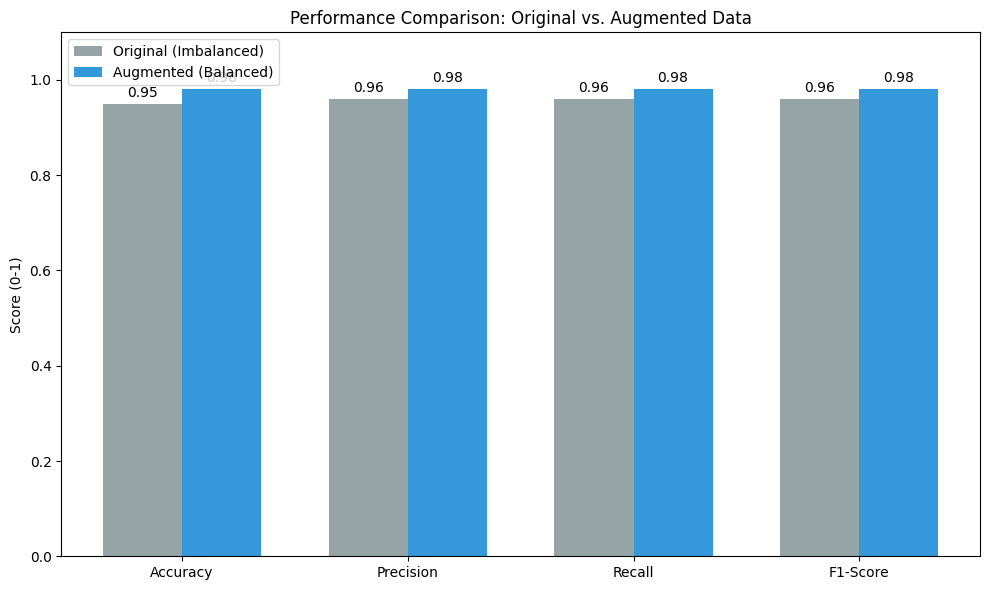

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, original_result, width, label='Original (Imbalanced)', color='#95a5a6')
rects2 = ax.bar(x + width/2, augmented_result, width, label='Augmented (Balanced)', color='#3498db')

ax.set_ylabel('Score (0-1)')
ax.set_title('Performance Comparison: Original vs. Augmented Data')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

# 5. ADD TEXT LABELS (This is what makes the numbers appear on bars)
ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

plt.tight_layout()
plt.show()

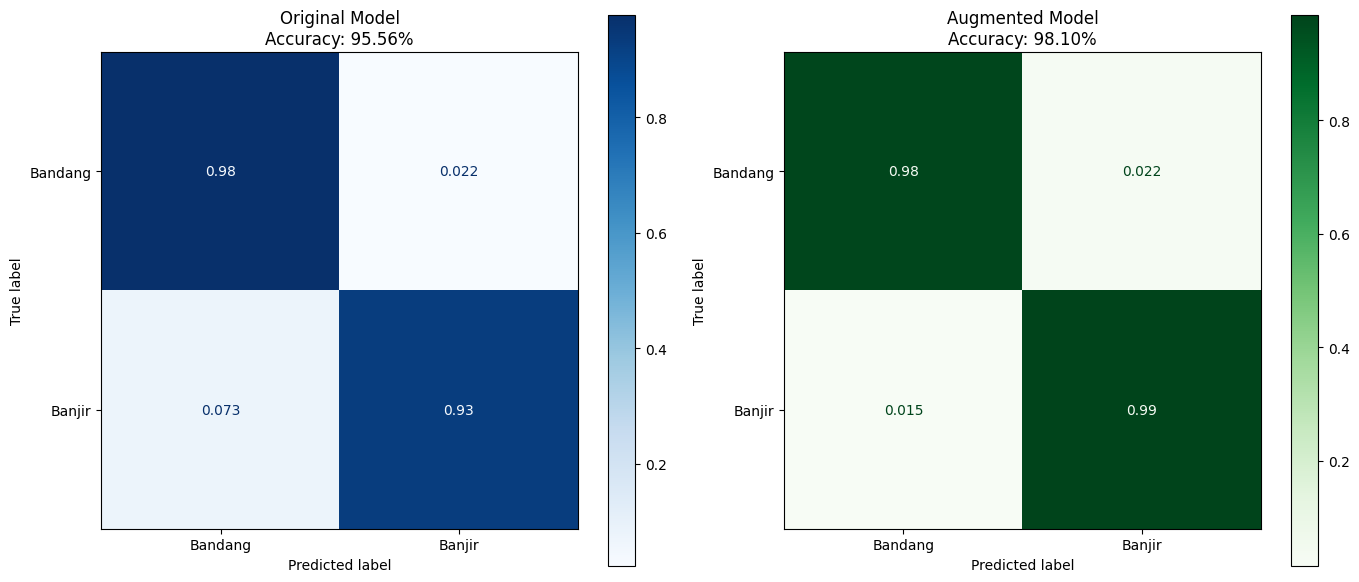

In [ ]:
# 2. Setup the subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 3. Original Model Plot
ConfusionMatrixDisplay.from_estimator(
    model_orig, X_test_fair_tfidf, y_test_fair,
    display_labels=['Bandang', 'Banjir'],
    normalize='true',
    cmap='Blues',
    ax=ax[0]
)
ax[0].set_title(f'Original Model\nAccuracy: {acc_orig:.2%}')

# 4. Augmented Model Plot
ConfusionMatrixDisplay.from_estimator(
    model_aug, X_test_fair_tfidf, y_test_fair,
    display_labels=['Bandang', 'Banjir'],
    normalize='true',
    cmap='Greens',
    ax=ax[1]
)
ax[1].set_title(f'Augmented Model\nAccuracy: {acc_aug:.2%}')

plt.tight_layout()
plt.show()
